In [160]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [161]:
# === 1. Carregar CSV ===
df = pd.read_csv("features.csv")

# Remove coluna de índice desnecessária se existir
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# === 2. Limpar coluna de rótulos ===
df["diagnostic_superclass"] = df["diagnostic_superclass"].str.replace(r"[\[\]']", "", regex=True)

# === 3. Separar X (features) e y (classes) ===
X = df.drop(columns=["diagnostic_superclass"])
y = df["diagnostic_superclass"]


In [162]:
# Codificar classes
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# === 4. Dividir treino/teste ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [168]:
# === 5. Treinar Random Forest para obter ranking das features ===
rf_full = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rf_full.fit(X_train, y_train)

# Obter as 22 melhores features
importances = rf_full.feature_importances_
indices = np.argsort(importances)[::-1]
top_22_features = [X.columns[i] for i in indices[:22]]

print(f"Acurácia RF:{rf_full.score(X_test, y_test):.2f}")

print("\n=== Top 22 Features Selecionadas ===")
for rank, feat in enumerate(top_22_features, start=1):
    print(f"{rank:2d}. {feat:30s} -> {importances[indices[rank-1]]:.4f}")

Acurácia RF:0.80

=== Top 22 Features Selecionadas ===
 1. band_energy_low_II             -> 0.0382
 2. band_energy_low_III            -> 0.0373
 3. band_energy_low_V1             -> 0.0370
 4. band_energy_high_II            -> 0.0321
 5. band_energy_low_aVF            -> 0.0297
 6. band_energy_mid_II             -> 0.0259
 7. age                            -> 0.0251
 8. band_energy_mid_III            -> 0.0235
 9. band_energy_low_V2             -> 0.0230
10. band_energy_mid_aVF            -> 0.0223
11. band_energy_low_V3             -> 0.0185
12. band_energy_mid_V2             -> 0.0180
13. band_energy_mid_V1             -> 0.0179
14. band_energy_mid_V3             -> 0.0164
15. band_energy_high_V1            -> 0.0155
16. band_energy_high_V2            -> 0.0134
17. band_energy_high_aVF           -> 0.0131
18. mean_qq_interval_s_II          -> 0.0127
19. mean_tt_interval_s_II          -> 0.0126
20. band_energy_high_III           -> 0.0124
21. mean_rr_interval_s_II          -> 0.0122


In [164]:
# === 6. Usar só as 22 melhores ===
X_train_top22 = X_train[top_22_features]
X_test_top22 = X_test[top_22_features]

# Escalar os dados (SVM funciona melhor com normalização)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_top22)
X_test_scaled = scaler.transform(X_test_top22)

In [165]:
# === 7. Treinar SVM ===
svm_model = SVC(kernel="rbf", C=10, gamma="scale", random_state=42, class_weight='balanced', decision_function_shape='ovr')
svm_model.fit(X_train_scaled, y_train)

# === 8. Avaliar no teste ===
y_pred_svm = svm_model.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)



✅ Acurácia do SVM com as 22 melhores features: 73.60%

=== Relatório de Classificação ===
              precision    recall  f1-score   support

          CD       0.53      0.69      0.60       274
          MI       0.40      0.68      0.51       348
        NORM       0.92      0.75      0.83      1795

    accuracy                           0.74      2417
   macro avg       0.62      0.71      0.65      2417
weighted avg       0.80      0.74      0.76      2417



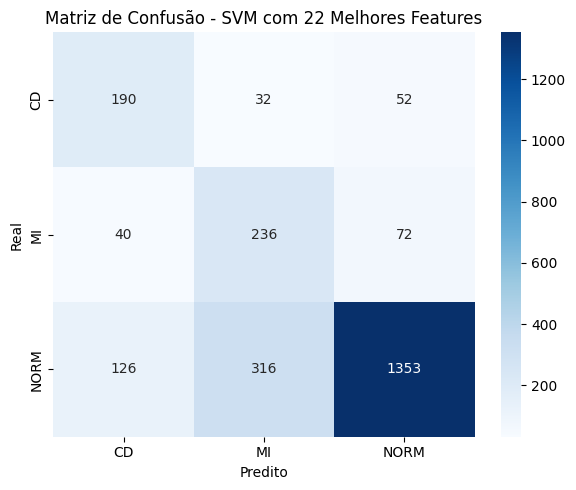

In [166]:

print(f"\n✅ Acurácia do SVM com as 22 melhores features: {acc_svm*100:.2f}%\n")
print("=== Relatório de Classificação ===")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - SVM com 22 Melhores Features")
plt.tight_layout()
plt.show()
